# UCI Adult - Analyzing Income Factors
**EPITA – MSc Artificial Intelligence Systems (AIS)**  
**Spark & Python for Big Data AIS S2 F25**

**Students:**
- TRUONG Kim Tan
- LE Linh Long
- Farouk RAHAL

---

## Step 0: Imports and Data Loading

In [1]:
# !pip3 install plotnine

### 0.1. Imports

In [2]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when, mean, count, sum as spark_sum, lit, udf
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

import warnings
warnings.filterwarnings('ignore')

### 0.2. Spark Session Initialization

In [3]:
spark = SparkSession.builder \
    .appName("AdultCensusIncome_Spark") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
spark.sparkContext.getConf().getAll()
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/03 16:03:59 WARN Utils: Your hostname, Longs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.41.177.87 instead (on interface en0)
26/03/03 16:03:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 16:03:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


### 0.3. Data Loading with Spark

In [4]:
csv_file = glob.glob(f"adult.csv", recursive=True)[0]

# Define schema
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("workclass", StringType(), True),
    StructField("fnlwgt", IntegerType(), True),
    StructField("education", StringType(), True),
    StructField("education_num", IntegerType(), True),
    StructField("marital_status", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("relationship", StringType(), True),
    StructField("race", StringType(), True),
    StructField("sex", StringType(), True),
    StructField("capital_gain", IntegerType(), True),
    StructField("capital_loss", IntegerType(), True),
    StructField("hours_per_week", IntegerType(), True),
    StructField("native_country", StringType(), True),
    StructField("income", StringType(), True)
])

df = spark.read.csv(csv_file, schema=schema, header=True,
                    nullValue="?",
                    ignoreLeadingWhiteSpace=True,
                    ignoreTrailingWhiteSpace=True)

df.cache()

print("Schema:")
df.printSchema()
print(f"Total records: {df.count():,}")
df.show(5, truncate=False)

Schema:
root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



Total records: 32,561
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education   |education_num|marital_status|occupation       |relationship |race |sex   |capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|90 |NULL     |77053 |HS-grad     |9            |Widowed       |NULL             |Not-in-family|White|Female|0           |4356        |40            |United-States |<=50K |
|82 |Private  |132870|HS-grad     |9            |Widowed       |Exec-managerial  |Not-in-family|White|Female|0           |4356        |18            |United-States |<=50K |
|66 |NULL     |186061|Some-college|10           |Widowed       |NULL             |Unmarried    |Black|Female|0   

### 0.4. Data Exploration

#### a. Dataset Overview

In [5]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



#### b. Missing Values

In [6]:
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education|education_num|marital_status|occupation|relationship|race|sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|  0|     1836|     0|        0|            0|             0|      1843|           0|   0|  0|           0|           0|             0|           583|     0|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+



#### c. Data Distribution

In [7]:
df.groupBy("income").count() \
  .withColumn("percentage", F.col("count") / df.count() * 100) \
  .show()

+------+-----+------------------+
|income|count|        percentage|
+------+-----+------------------+
| <=50K|24720| 75.91904425539757|
|  >50K| 7841|24.080955744602438|
+------+-----+------------------+



#### d. Correlation Matrix

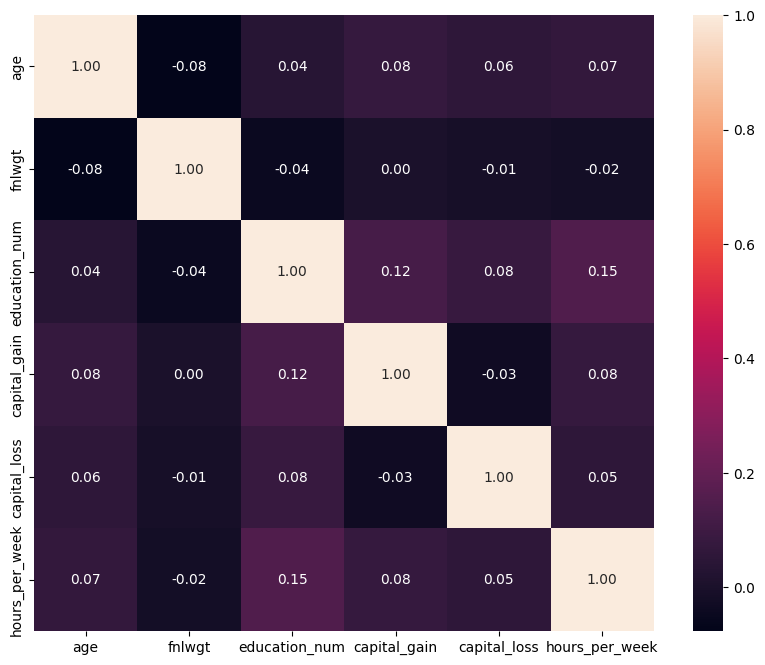

In [8]:
numeric_cols = [c for c, t in df.dtypes if t in ["int", "double"]]
pdf = df.select(numeric_cols).toPandas()

plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), annot=True, fmt=".2f")
plt.show()

---

## Step 1: Data Cleaning and Preparation

### 1.1. Handling Missing Values

#### a. Creating $Unknown$ category for missing values

In [9]:
df_imputed = df.withColumn(
    'workclass',
    F.when(F.isnull('workclass'), "Unknown").otherwise(F.col('workclass'))
).withColumn(
    'occupation',
    F.when(F.isnull('occupation'), "Unknown").otherwise(F.col('occupation'))
).withColumn(
    'native_country',
    F.when(F.isnull('native_country'), "Unknown").otherwise(F.col('native_country'))
)

#### b. Verification

In [10]:
print(f"Workclass nulls remaining: {df_imputed.filter(F.isnull('workclass')).count():,}")
print(f"Occupation nulls remaining: {df_imputed.filter(F.isnull('occupation')).count():,}")
print(f"Native country nulls remaining: {df_imputed.filter(F.isnull('native_country')).count():,}")

df = df_imputed

Workclass nulls remaining: 0
Occupation nulls remaining: 0
Native country nulls remaining: 0


### 1.2. Redundancy Check

#### a. Unique combinations of `education` and `education_num`

In [11]:
education_mapping = df.groupBy("education", "education_num").count().orderBy("education_num")
education_mapping.show(truncate=False)

print(f"Total unique education levels: {df.select('education').distinct().count()}")
print(f"Total unique education_num values: {df.select('education_num').distinct().count()}")

+------------+-------------+-----+
|education   |education_num|count|
+------------+-------------+-----+
|Preschool   |1            |51   |
|1st-4th     |2            |168  |
|5th-6th     |3            |333  |
|7th-8th     |4            |646  |
|9th         |5            |514  |
|10th        |6            |933  |
|11th        |7            |1175 |
|12th        |8            |433  |
|HS-grad     |9            |10501|
|Some-college|10           |7291 |
|Assoc-voc   |11           |1382 |
|Assoc-acdm  |12           |1067 |
|Bachelors   |13           |5355 |
|Masters     |14           |1723 |
|Prof-school |15           |576  |
|Doctorate   |16           |413  |
+------------+-------------+-----+

Total unique education levels: 16
Total unique education_num values: 16


#### b. One-to-one Mapping Check

In [12]:
mapping_count = education_mapping.count()
unique_education = df.select("education").distinct().count()
unique_education_num = df.select("education_num").distinct().count()

print(f"Number of (education, education_num) pairs: {mapping_count}")

if mapping_count == unique_education == unique_education_num:
    print("Every education label maps to exactly one education_num")

    # Show the mapping for reference
    print("Education Mapping Reference: ")
    mapping_df = education_mapping.select("education", "education_num").orderBy("education_num")
    mapping_df.show(truncate=False)

Number of (education, education_num) pairs: 16
Every education label maps to exactly one education_num
Education Mapping Reference: 
+------------+-------------+
|education   |education_num|
+------------+-------------+
|Preschool   |1            |
|1st-4th     |2            |
|5th-6th     |3            |
|7th-8th     |4            |
|9th         |5            |
|10th        |6            |
|11th        |7            |
|12th        |8            |
|HS-grad     |9            |
|Some-college|10           |
|Assoc-voc   |11           |
|Assoc-acdm  |12           |
|Bachelors   |13           |
|Masters     |14           |
|Prof-school |15           |
|Doctorate   |16           |
+------------+-------------+



From the One-to-one mapping check, we can see that:
- Every education label maps to exactly 1 education_num
- And every education_num maps to exactly 1 education label
So the relationship is 1-to-1. Therefore, we'll drop the `education` column and keep the `education_num` because we want to work with numerical features for machine learning.

#### c. Redundancy Drop

In [13]:
df = df.drop("education")

### 1.3. Categorical Columns Cleaning

#### a. Categorical Columns

In [14]:
categorical_cols = [field.name for field in df.schema.fields if str(field.dataType) == "StringType()"]
print(f"Categorical columns: {categorical_cols}")


Categorical columns: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


#### b. Categorical Columns Cleaning

In [15]:
whitespace_cleaned = []
for col_name in categorical_cols:
    print(f"Checking column: '{col_name}'")

    # We will check for leading/trailing whitespace using rlike (regex)
    has_whitespace = df.filter(F.col(col_name).rlike("^\\s+|\\s+$")).count()

    print(f"  Records with surrounding whitespace: {has_whitespace}")

    if has_whitespace > 0:
        print(f"  Cleaning whitespace in '{col_name}'")
        df = df.withColumn(col_name, F.trim(F.col(col_name)))
        whitespace_cleaned.append(col_name)
    else:
        print(f"  No surrounding whitespace found in '{col_name}'")

print("-"*40)
print(f"Whitespace Cleaning Summary")
print("-"*40)
if whitespace_cleaned:
    print(f"Cleaned columns: {whitespace_cleaned}")
else:
    print("No whitespace issues found in any columns")

Checking column: 'workclass'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'workclass'
Checking column: 'marital_status'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'marital_status'
Checking column: 'occupation'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'occupation'
Checking column: 'relationship'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'relationship'
Checking column: 'race'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'race'
Checking column: 'sex'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'sex'
Checking column: 'native_country'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'native_country'
Checking column: 'income'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'income'
----------------------------------------
Whitesp

---

## Step 2 : Feature Transformation and Engineering

### 2.1. Target Transformation

In [16]:
df = df.withColumn(
    "label",
    F.when(F.col("income") == ">50K", 1).otherwise(0)
).drop("income") # convert the income column into a binary integer label

df.groupBy("label").count().show() 

+-----+-----+
|label|count|
+-----+-----+
|    1| 7841|
|    0|24720|
+-----+-----+



### 2.2. Analyzing Capital Gains/Losse

In [17]:
df = df.withColumn("net_capital", F.col("capital_gain") - F.col("capital_loss")) #create a new feature representing the capital income
df.groupBy("label") \
  .agg(F.avg("net_capital").alias("avg_net_capital"),
       F.count("*").alias("count")) \
  .orderBy("label") \
  .show() #  visualize the average net capital between classes
df = df.drop("capital_gain", "capital_loss")

+-----+------------------+-----+
|label|   avg_net_capital|count|
+-----+------------------+-----+
|    0| 95.60954692556635|24720|
|    1|3811.1409259023085| 7841|
+-----+------------------+-----+



### 2.3. Grouping Countries

In [18]:
df.groupBy("native_country").count().orderBy(F.desc("count")).show(truncate=False)

+------------------+-----+
|native_country    |count|
+------------------+-----+
|United-States     |29170|
|Mexico            |643  |
|Unknown           |583  |
|Philippines       |198  |
|Germany           |137  |
|Canada            |121  |
|Puerto-Rico       |114  |
|El-Salvador       |106  |
|India             |100  |
|Cuba              |95   |
|England           |90   |
|Jamaica           |81   |
|South             |80   |
|China             |75   |
|Italy             |73   |
|Dominican-Republic|70   |
|Vietnam           |67   |
|Guatemala         |64   |
|Japan             |62   |
|Poland            |60   |
+------------------+-----+
only showing top 20 rows


In [19]:
df = df.withColumn( # change every other country other than USA to be other, to avoid curse of dimensionality when applying One Hot Encoder
    "native_country",
    F.when(F.col("native_country") == "United-States", "United-States")
     .otherwise("Other")
)

df.groupBy("native_country").count().orderBy(F.desc("count")).show()

+--------------+-----+
|native_country|count|
+--------------+-----+
| United-States|29170|
|         Other| 3391|
+--------------+-----+



### 2.4. Age Discretization

In [20]:
df = df.withColumn(
    "age_group",
    F.when(F.col("age") < 25, "Under 25")
     .when(F.col("age") < 35, "25-34")
     .when(F.col("age") < 45, "35-44")
     .when(F.col("age") < 55, "45-54")
     .when(F.col("age") < 65, "55-64")
     .otherwise("65+")
)

df.groupBy("age_group").count().orderBy(F.desc("count")).show()

+---------+-----+
|age_group|count|
+---------+-----+
|    25-34| 8479|
|    35-44| 8151|
|    45-54| 5853|
| Under 25| 5570|
|    55-64| 3172|
|      65+| 1336|
+---------+-----+



### 2.5. Export Processed Data

In [21]:
df_pandas = df.toPandas()
df_pandas.to_csv("processed.csv")

---

## Step 3: Unsupervised Learning

### 3.1. Pipeline Building

We extract the numerical features, scaling the data to create Standard Scaler, to create a Pipeline for Unsupervised Learning

In [22]:
numeric_types = ['int', 'double', 'float']
num_cols = [col for col, dtype in df.dtypes if dtype in numeric_types and col != 'label']

assembler = VectorAssembler(inputCols=num_cols, outputCol="assembled_features")
scaler = StandardScaler(inputCol="assembled_features", outputCol="features", withStd=True, withMean=True)
pca = PCA(k=2, inputCol="features", outputCol="pca_features")

pipeline_ul = Pipeline(stages=[assembler, scaler, pca])
pipeline_ul_model = pipeline_ul.fit(df)
result_ul = pipeline_ul_model.transform(df)

Setting k=2 for PCA to check it's seperation, and to see it's explained variance

Total Variance Captured: 46.30%


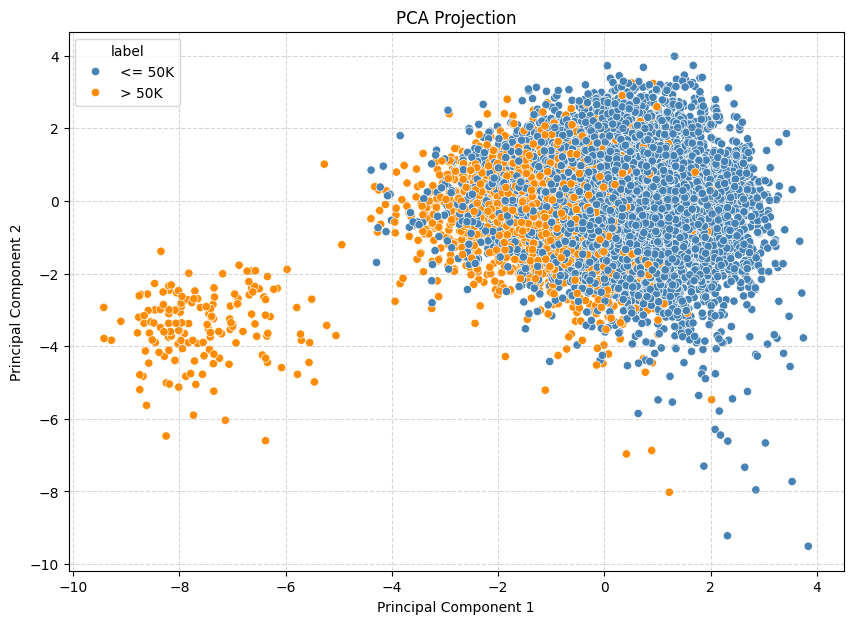

In [23]:
def extract_pca_fn(vec, idx):
    return float(vec[idx])

extract_pca_udf = udf(extract_pca_fn)

plot_df = result_ul.select(
    vector_to_array("pca_features").alias("pca_array"), 
    "label"
).select(
    col("pca_array")[0].alias("PC1"),
    col("pca_array")[1].alias("PC2"),
    "label"
).toPandas()

pca_model = pipeline_ul_model.stages[2]
variance_ratios = pca_model.explainedVariance.toArray()
total_var = sum(variance_ratios) * 100
print(f"Total Variance Captured: {total_var:.2f}%")

label_map = {0: '<= 50K', 1: '> 50K'}
plot_df['label'] = plot_df['label'].map(label_map)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", palette={'<= 50K': 'steelblue', '> 50K': 'darkorange'})
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

As observed from the graph, there is a clear separation showed by the isolated cluster of Label 1 whose color is orange on the far left, but a significant overlap zone exists where the two classes are heavily merged. This shows that the PCA with k=2 cannot help seperate the data efficiently and correctly into our 2 desired label groups.

---

## Step 4: Data Visualization

### a. Education vs Income

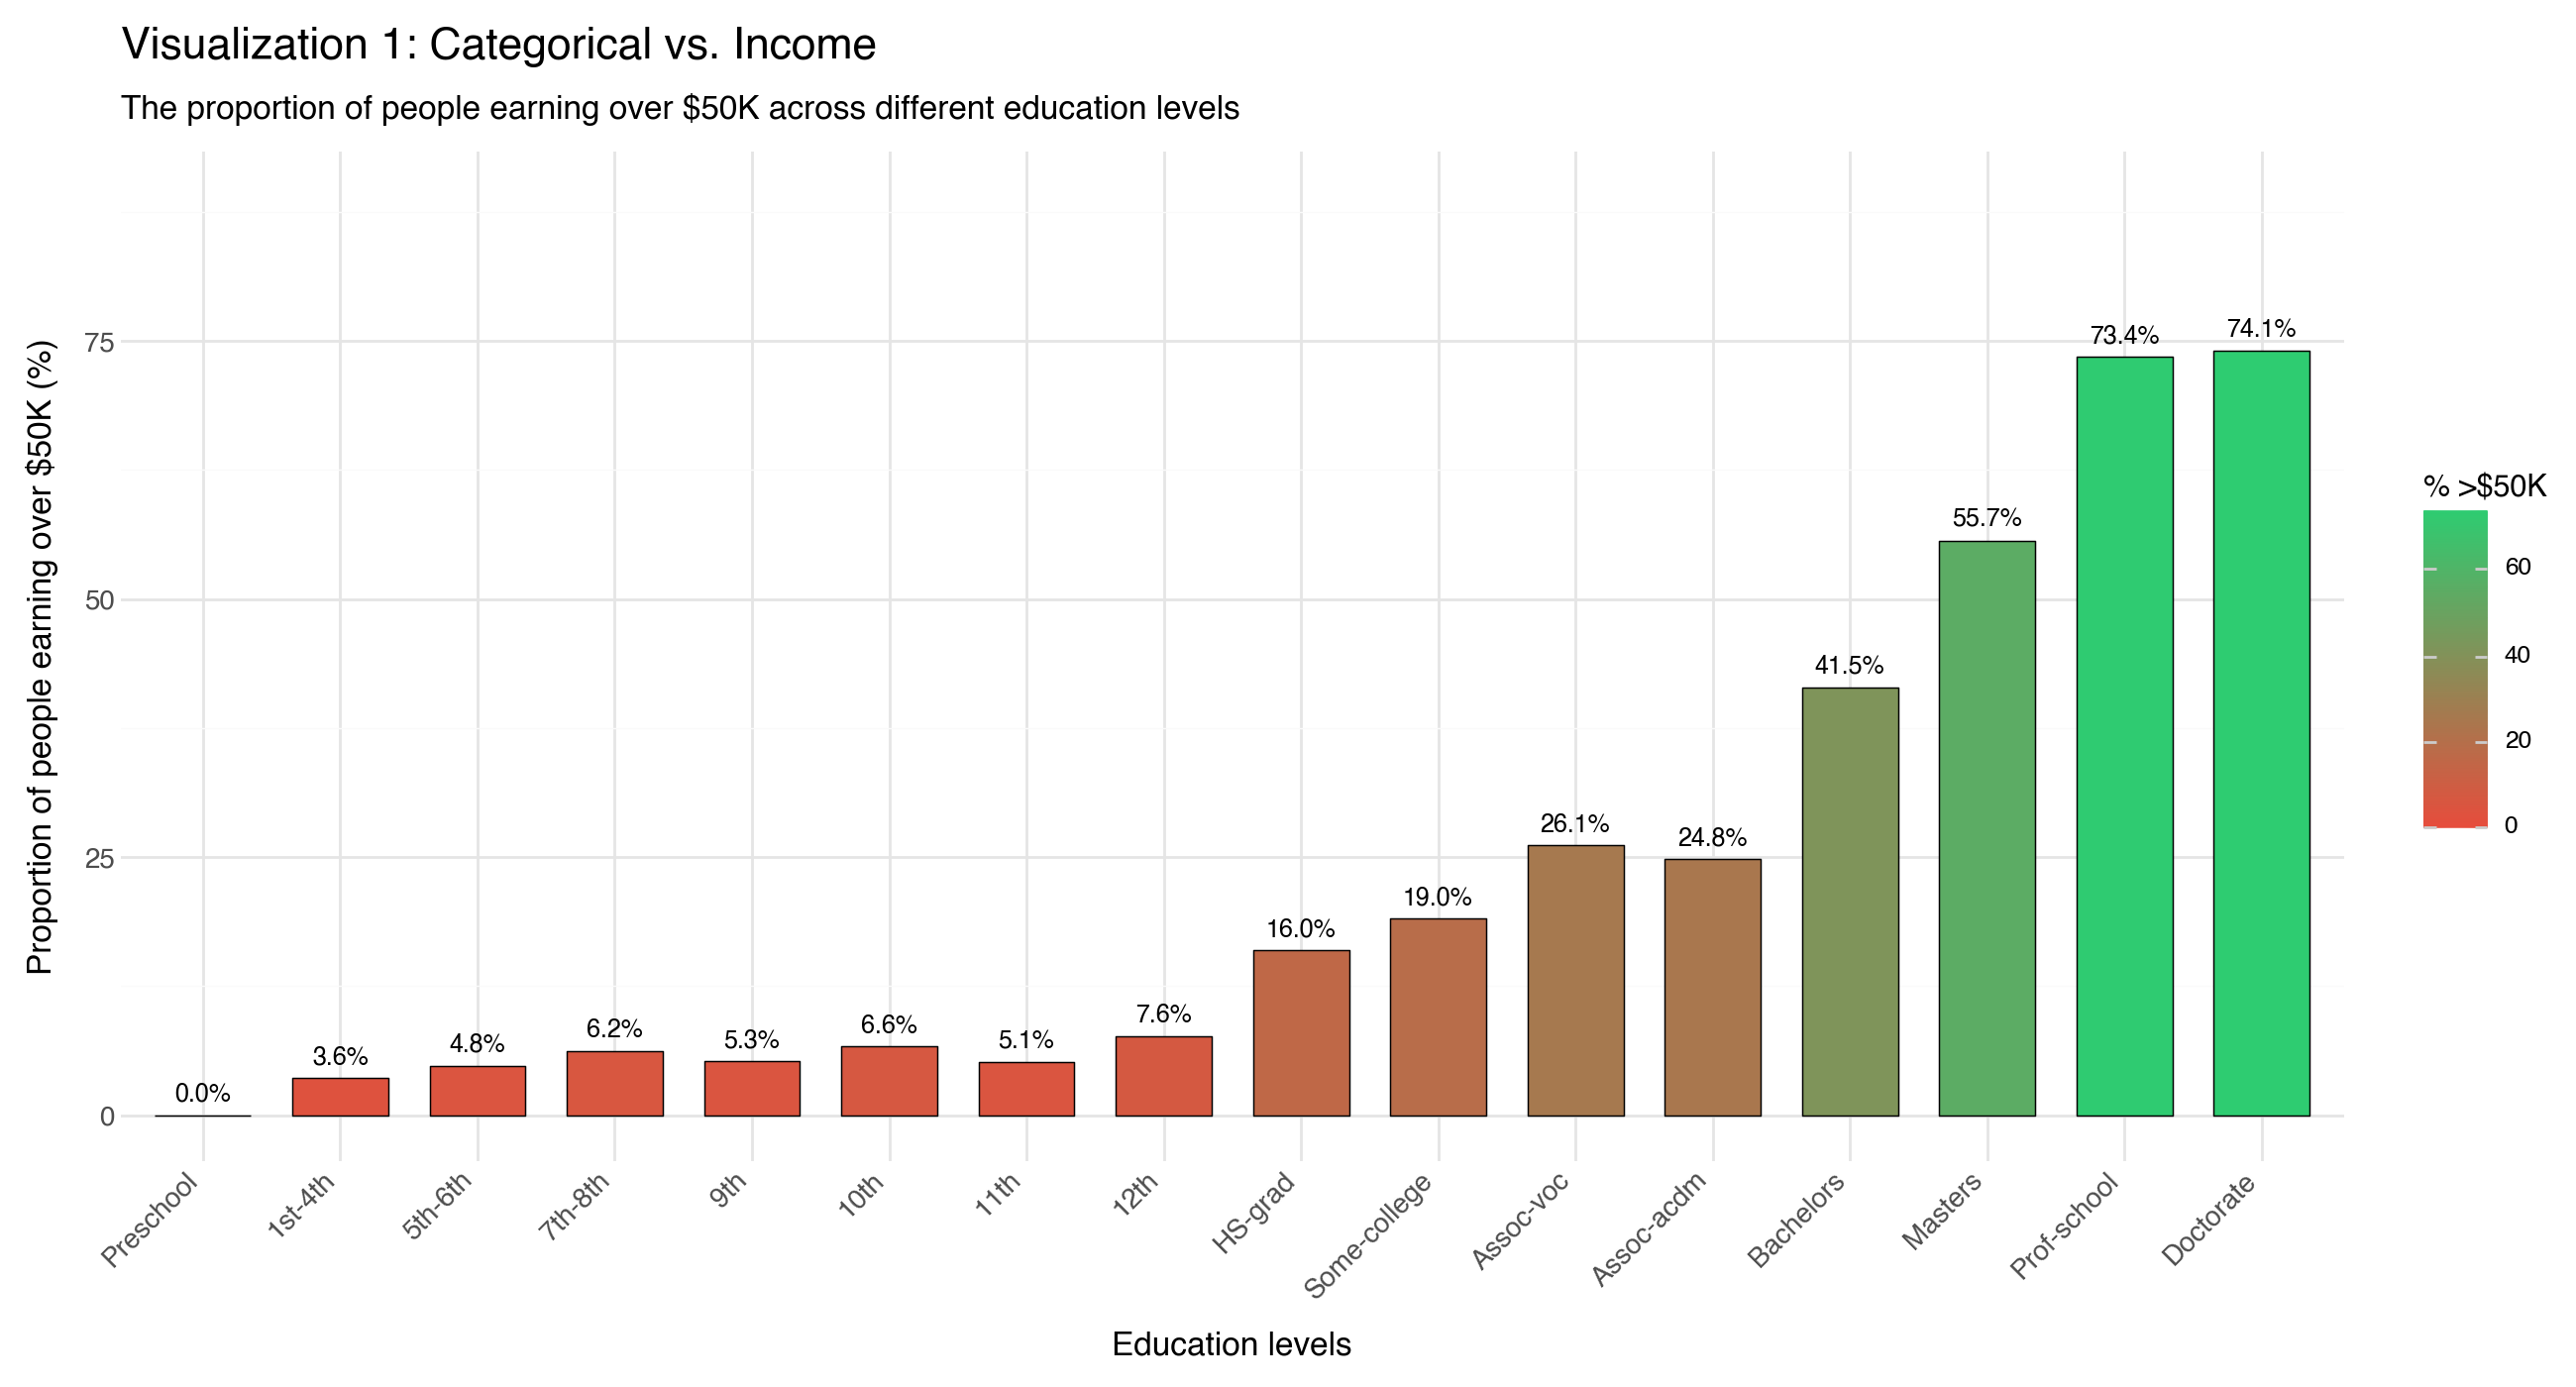

In [24]:
edu_order_df = education_mapping.select("education").collect()
education_order = [row.education for row in edu_order_df]

viz1_spark = df_imputed.groupBy('education').agg(
    (spark_sum(when(col('income') == '>50K', 1).otherwise(0)) / count('*') * 100).alias('pct_over_50k'),
    count('*').alias('count')
)

# We convert to Pandas and then set existing education as ordered categorical
viz1_pd = viz1_spark.toPandas()
viz1_pd['education'] = pd.Categorical(
    viz1_pd['education'], 
    categories=education_order, 
    ordered=True
)
viz1_pd = viz1_pd.sort_values('education')

plot1 = (
    ggplot(viz1_pd, aes(x='education', y='pct_over_50k', fill='pct_over_50k')) +
    geom_bar(stat='identity', color='black', size=0.3, width=0.7) +
    geom_text(
        aes(label='pct_over_50k.round(1).astype(str) + "%"'), 
        nudge_y=2, 
        size=9, 
        fontweight='bold'
    ) +
    scale_fill_gradient(low='#e74c3c', high='#2ecc71', name='% >$50K') +
    labs(
        title='Visualization 1: Categorical vs. Income',
        subtitle='The proportion of people earning over $50K across different education levels',
        x='Education levels',
        y='Proportion of people earning over $50K (%)',
    ) +
    theme_minimal() +
    theme(
        plot_title=element_text(face='bold', size=16),
        plot_subtitle=element_text(size=12),
        axis_text_x=element_text(angle=45, hjust=1, size=10),
        axis_text_y=element_text(size=10),
        axis_title=element_text(face='bold', size=12),
        legend_position='right',
        figure_size=(13, 7)
    ) +
    ylim(0, max(viz1_pd['pct_over_50k']) * 1.2)
)

plot1.show()

The data reveals an almost linear relationship between education and earning power: as education levels increase, so does the likelihood of earning over $50k. 
- The jump is particularly significant at the college level, while only about a quarter of those with vocational or associate degrees earn above $50K, that figure nearly doubles to 41.5% for Bachelor's holders and skyrockets to over 70% for advanced degrees.
- What's more notable isn't just the trend itself, but how sharply the curve accelerates. The gap between a Master's (55.7%) and a professional degree (73.4%) is nearly as wide as the entire span from preschool through high school combined.

It suggests that in this dataset, the real financial payoff is the level of education.

### b. Age vs Income

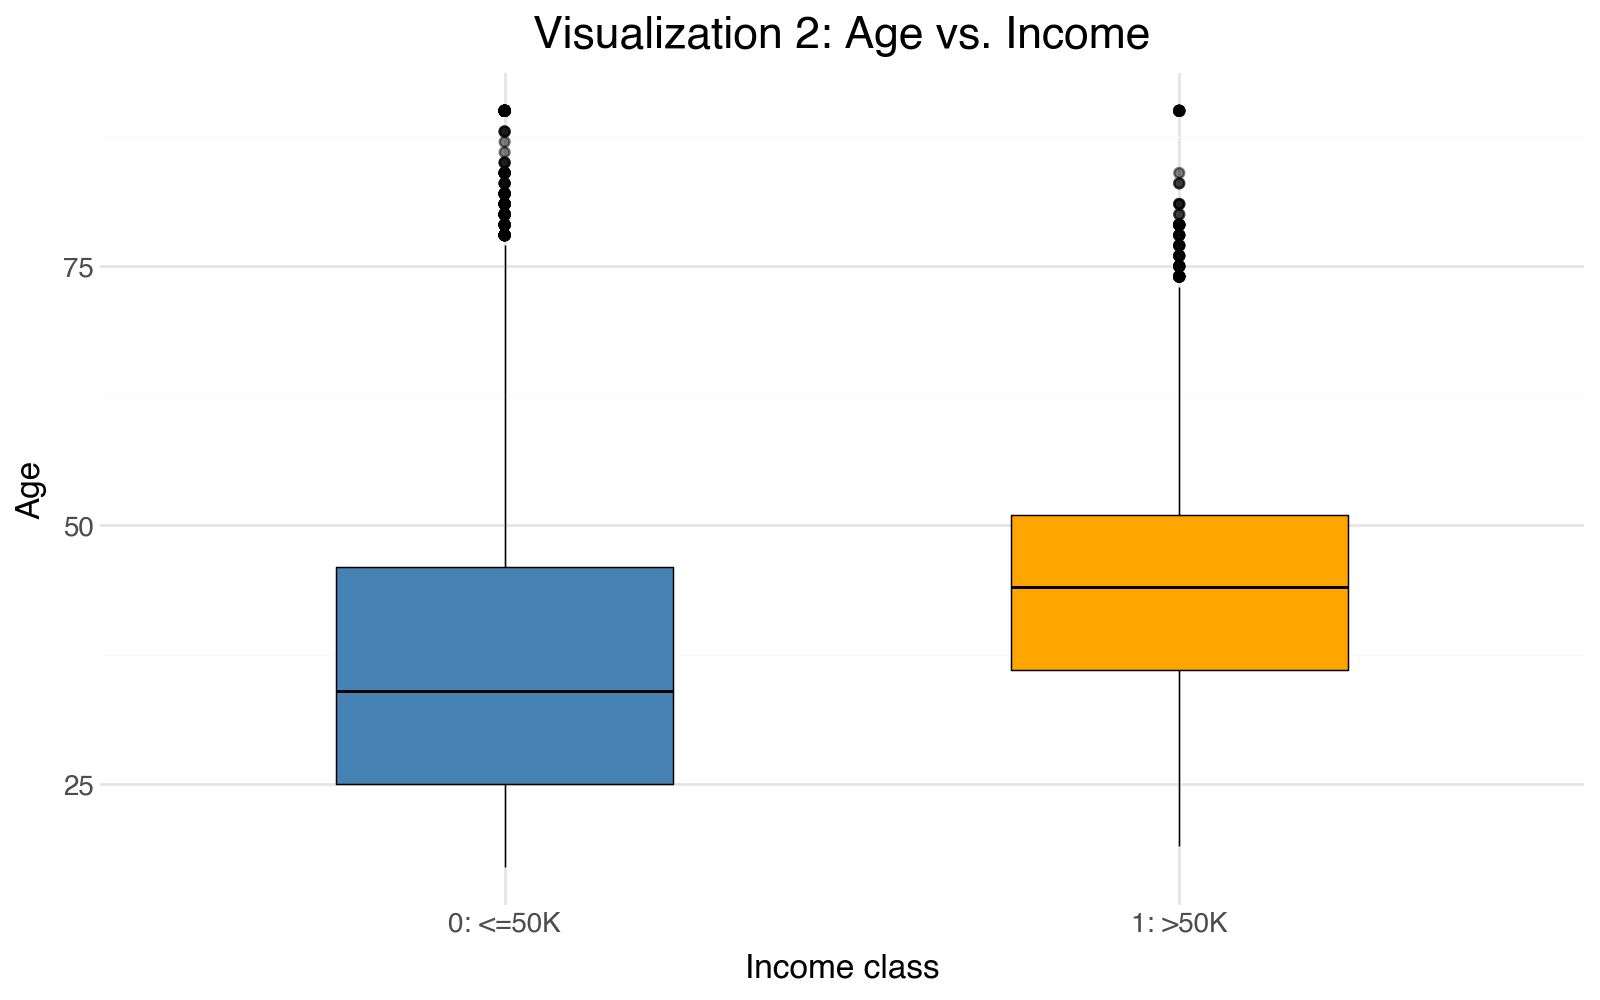

In [25]:
age_pdf = df.select("age", "label").toPandas()

# Convert label to string to ensure it's treated as discrete
age_pdf['label'] = age_pdf['label'].astype(str)

plot2 = (
    ggplot(age_pdf, aes(x='label', y='age', fill='label')) +
    geom_boxplot(color='black', size=0.3, width=0.5, outlier_alpha=0.5) +
    scale_fill_manual(values={'0': 'steelblue', '1': 'orange'}, guide=None) +
    scale_x_discrete(labels={'0': '0: <=50K', '1': '1: >50K'}) +
    labs(
        title='Visualization 2: Age vs. Income',
        x='Income class',
        y='Age',
    ) +
    theme_minimal() +
    theme(
        plot_title=element_text(face='bold', size=16),
        axis_text_x=element_text(size=10),
        axis_text_y=element_text(size=10),
        axis_title=element_text(face='bold', size=12),
        figure_size=(8, 5)
    )
)

plot2.show()

The data shows a clear age range in earnings: higher earners skew noticeably older. 
- The median age for those making over $50K sits around 42, almost a decade higher than the under $50K group's median of about 34. Both groups span similar age ranges

This suggests that while age alone doesn't guarantee crossing the $50K threshold, there's a strong association between career longevity and income growth. The prime age for earning power appears to be from 40s to 50s.

### c. Occupation vs Income

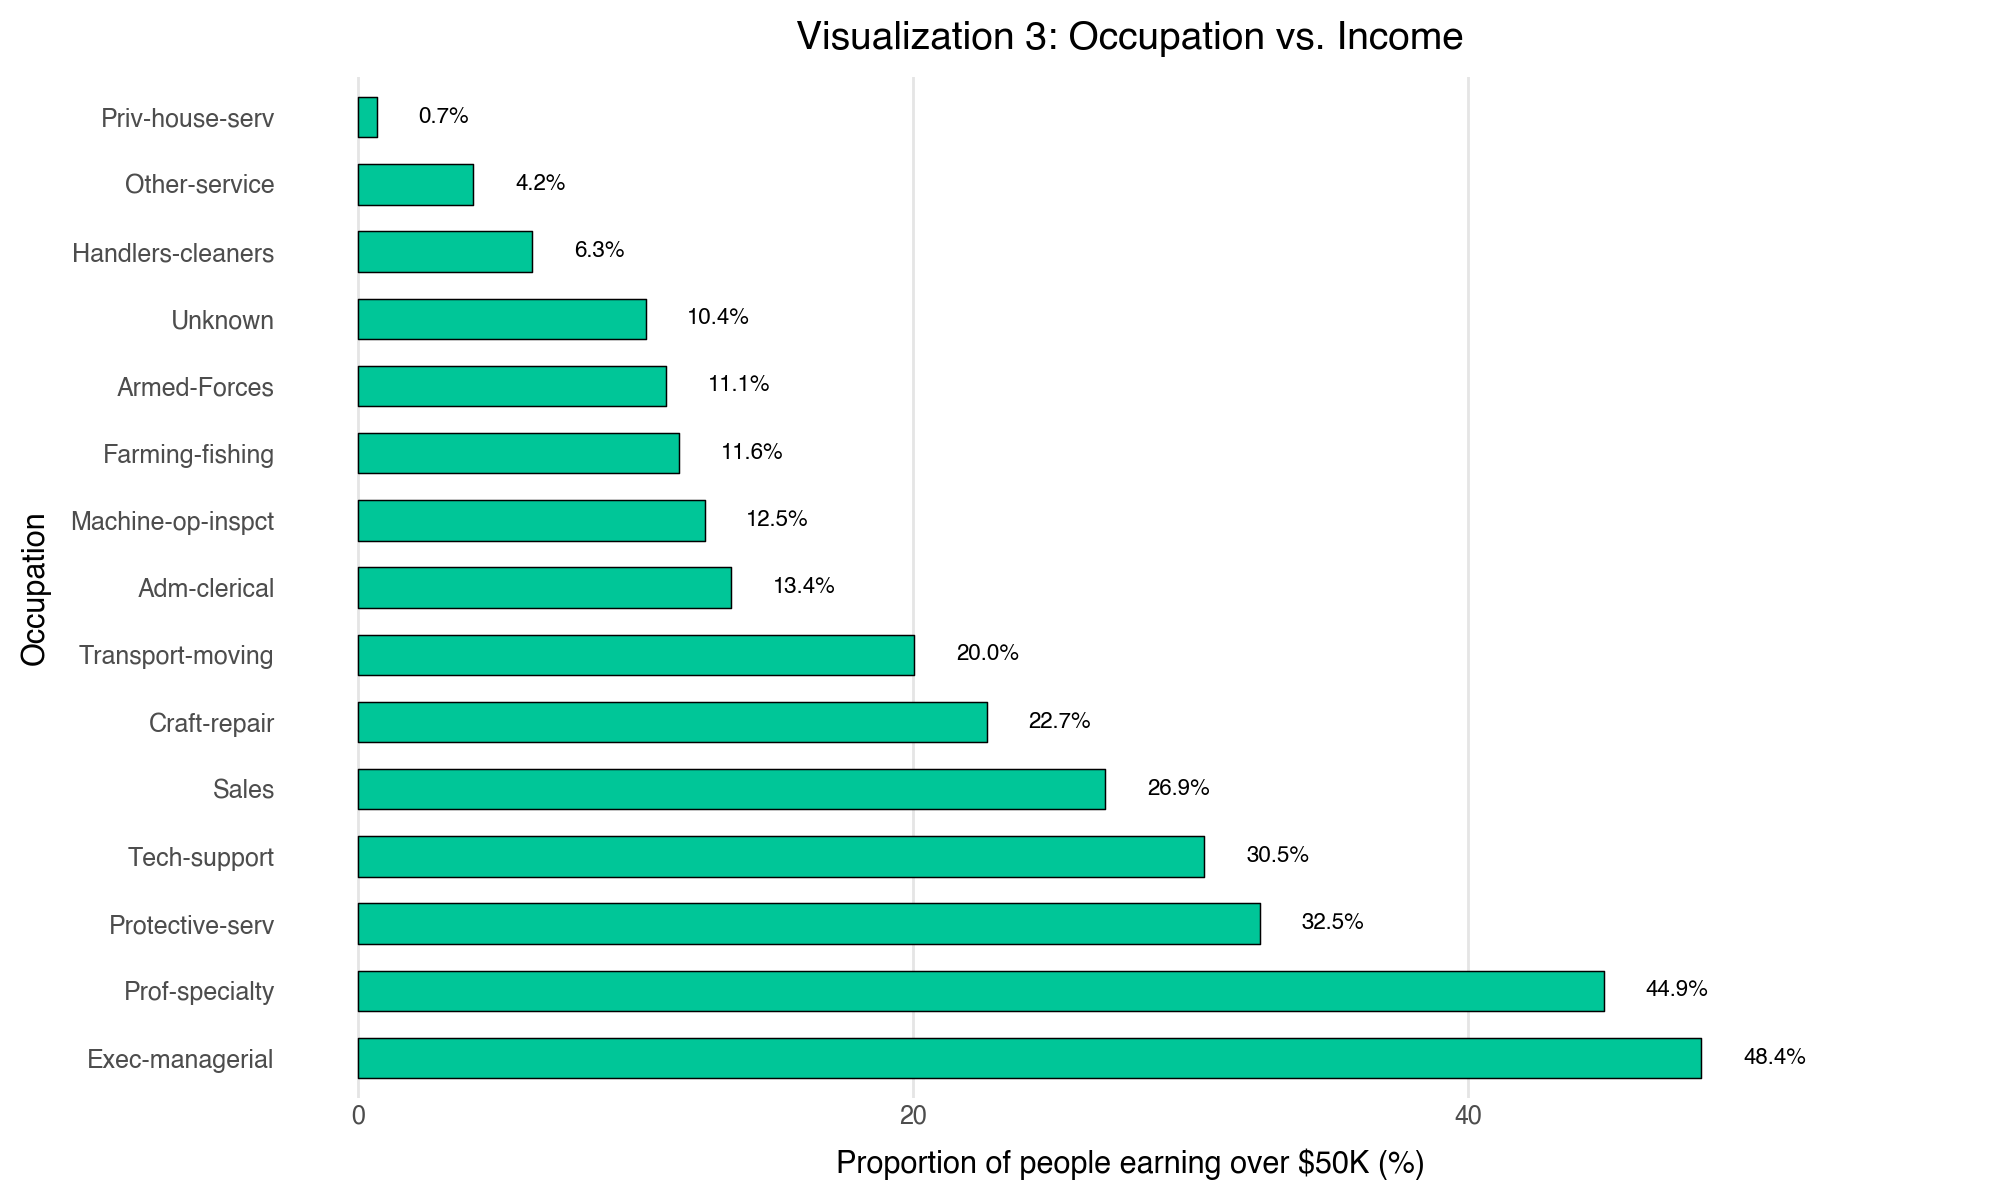

In [26]:
occ_pdf = df.groupBy("occupation", "label").count().toPandas()

total = occ_pdf.groupby("occupation")["count"].sum().reset_index(name="total")
over50 = occ_pdf[occ_pdf["label"] == 1][["occupation", "count"]].rename(columns={"count": "over50"})
plot3 = total.merge(over50, on="occupation")
plot3["pct"] = plot3["over50"] / plot3["total"] * 100

# Sort ascending for the plot (lowest at top, highest at bottom to match image 1)
plot3 = plot3.sort_values("pct", ascending=True)

# Convert occupation to ordered categorical - reversed order for plotnine
# plotnine plots first category at bottom, so we need descending order in categories
plot3["occupation"] = pd.Categorical(
    plot3["occupation"], 
    categories=plot3.sort_values("pct", ascending=False)["occupation"].tolist(), 
    ordered=True
)

plot3 = (
    ggplot(plot3, aes(x='occupation', y='pct')) +
    geom_bar(stat='identity', fill='#00c698', color='black', size=0.3, width=0.6) +
    geom_text(
        aes(label='pct.round(1).astype(str) + "%"'), 
        nudge_y=1.5, 
        size=8, 
        fontweight='bold',
        ha='left'
    ) +
    coord_flip() +
    labs(
        title='Visualization 3: Occupation vs. Income',
        x='Occupation',
        y='Proportion of people earning over $50K (%)',
    ) +
    theme_minimal() +
    theme(
        plot_title=element_text(face='bold', size=14, ha='center'),
        axis_text_x=element_text(size=9),
        axis_text_y=element_text(size=9),
        axis_title=element_text(face='bold', size=11),
        figure_size=(10, 6),
        panel_grid_major_y=element_blank(),
        panel_grid_minor=element_blank()
    ) +
    ylim(0, max(plot3['pct']) * 1.15)
)

plot3.show()

The data illustrates the proportion of people earning over $50k across occupations
- The contrast is significant at the top end: nearly half of individuals in executive-managerial roles, 48.4% and 44.9% in professional specialties earn over $50K. This places them far ahead of most other categories.
- A noticeable middle tier emerges with technical support (30.5%), protective services (32.5%), and sales (26.9%).
- At the lower end, service-oriented and manual labor occupations such as handlers-cleaners (6.3%), other-service (4.2%), and private household services (0.7%) show limited access to higher income group.

Overall, the visualization suggests that occupation groups can play a factor in earning over $50K.

---

## Step 5: Modeling and Prediction

### 5.0 Train Test Split

In [ ]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=36)
print("Train count:", train_df.count())
print("Test count:", test_df.count())

df = df.drop("age") # drop age to avoid redundance

Train count: 26167
Test count: 6394


### 5.1. Pipeline Building

We apply One-Hot Encoder for categorical features, and then we scaled the data using Standard Scaler, to generate a Pipeline for Supervised Learning

In [28]:
cat_cols = ["workclass",  "marital_status", "occupation","relationship", "race", "sex", "native_country", "age_group"]
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_indexed",
        handleInvalid="keep"
    )
    for col in cat_cols
]

encoders = [
    OneHotEncoder(
        inputCol=col + "_indexed",
        outputCol=col + "_ohe"
    )
    for col in cat_cols
]

assembler = VectorAssembler(
    inputCols=num_cols + [col + "_ohe" for col in cat_cols],
    outputCol="assembled_features"
)

scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features",
    withStd=True,
    withMean=True
)

pipeline_sl = Pipeline(stages=indexers + encoders + [assembler, scaler])

pipeline_sl_model = pipeline_sl.fit(train_df) # we dont fit on test set to avoid data leakage
train_result = pipeline_sl_model.transform(train_df)
test_result = pipeline_sl_model.transform(test_df)

train_result = train_result.select("features", "label")
test_result = test_result.select("features", "label")

### 5.2. Logistic Regression

#### a. Model Hyperparameter Tuning

In [29]:
model_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

param_grid_lr = ( # apply hyperparameter tuning to find the best parameter for this dataset
    ParamGridBuilder()
    .addGrid(model_lr.regParam, [0.01, 0.1, 0.5])
    .addGrid(model_lr.elasticNetParam, [0.0, 0.5, 1.0])
    .addGrid(model_lr.maxIter, [50, 100])
    .build()
)

evaluator_auc_lr = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

cv_lr = CrossValidator(
    estimator=model_lr,  
    estimatorParamMaps=param_grid_lr,  # grid of hyperparameter combinations to evaluate
    evaluator=evaluator_auc_lr,  
    numFolds=3,  # perform 3 fold cross validation to reduce variance in performance estimates
    parallelism=2,  # run 2 models in parallel to speed up training
    seed=36  # reproducibility purpose
)

cv_model_lr = cv_lr.fit(train_result)
best_model_lr = cv_model_lr.bestModel 

print("===== Cross Validation Results =====")
for metric, params in zip(cv_model_lr.avgMetrics, param_grid_lr):
    print(
        f"AUC: {metric:.6f} | "
        f"regParam={params[model_lr.regParam]}, "
        f"elasticNetParam={params[model_lr.elasticNetParam]}, "
        f"maxIter={params[model_lr.maxIter]}"
    )
print()
print("===== Best Hyperparameters =====")
print("regParam        :", best_model_lr._java_obj.getRegParam())
print("elasticNetParam :", best_model_lr._java_obj.getElasticNetParam())
print("maxIter         :", best_model_lr._java_obj.getMaxIter())

===== Cross Validation Results =====
AUC: 0.902325 | regParam=0.01, elasticNetParam=0.0, maxIter=50
AUC: 0.902325 | regParam=0.01, elasticNetParam=0.0, maxIter=100
AUC: 0.900812 | regParam=0.01, elasticNetParam=0.5, maxIter=50
AUC: 0.900811 | regParam=0.01, elasticNetParam=0.5, maxIter=100
AUC: 0.896634 | regParam=0.01, elasticNetParam=1.0, maxIter=50
AUC: 0.896635 | regParam=0.01, elasticNetParam=1.0, maxIter=100
AUC: 0.894560 | regParam=0.1, elasticNetParam=0.0, maxIter=50
AUC: 0.894560 | regParam=0.1, elasticNetParam=0.0, maxIter=100
AUC: 0.870180 | regParam=0.1, elasticNetParam=0.5, maxIter=50
AUC: 0.870180 | regParam=0.1, elasticNetParam=0.5, maxIter=100
AUC: 0.850311 | regParam=0.1, elasticNetParam=1.0, maxIter=50
AUC: 0.850311 | regParam=0.1, elasticNetParam=1.0, maxIter=100
AUC: 0.886027 | regParam=0.5, elasticNetParam=0.0, maxIter=50
AUC: 0.886027 | regParam=0.5, elasticNetParam=0.0, maxIter=100
AUC: 0.500000 | regParam=0.5, elasticNetParam=0.5, maxIter=50
AUC: 0.500000 | regP

At 0.01 regParam, elasticNetParam and max iteration = 50 and 100, the model achieves the best AUC values. However, since 50 is less than 100, 50 iterations is the best parameter for Linear Regression in this dataset

#### b. Model Evaluation

In [30]:
test_predictions_lr = best_model_lr.transform(test_result)
test_auc_lr = evaluator_auc_lr.evaluate(test_predictions_lr)

evaluator_accuracy_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy_lr = evaluator_accuracy_lr.evaluate(test_predictions_lr)
f1_lr = evaluator_f1_lr.evaluate(test_predictions_lr)
precision_lr = evaluator_precision_lr.evaluate(test_predictions_lr)
recall_lr = evaluator_recall_lr.evaluate(test_predictions_lr)

print("===== Logistic Regression Test Metrics =====")
print(f"AUC       : {test_auc_lr:.4f}")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print()
print("===== Confusion Matrix =====")
test_predictions_lr.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

===== Logistic Regression Test Metrics =====
AUC       : 0.9034
Accuracy  : 0.8499
Precision : 0.8429
Recall    : 0.8499
F1 Score  : 0.8435

===== Confusion Matrix =====
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 4536|
|    0|       1.0|  320|
|    1|       0.0|  640|
|    1|       1.0|  898|
+-----+----------+-----+



Logistic Regression model performs well on the test dataset, with an AUC of 0.9034, showing strong discrimination ability between people earning >$50K and those earning <= $50K. The overall accuracy is 0.8499, however, since class distribution is imbalanced, accuracy alone does not fully reflect model quality. From the confusion matrix, the model correctly predicts 898 individuals in the >$50K class, while 640 high-income individuals are misclassified as <= $50K, showing that recall for the positive class can still be improved. The precision and recall values, both around 0.84, demonstrate a relatively balanced performance in identifying high-income individuals while controlling false positive predictions.

### 5.3. Random Forest

#### a. Model Hyperparameter Tuning

In [31]:
model_rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=36 # reproducibility purpose
)

param_grid_rf = ( # same thing as Logistic Regression
    ParamGridBuilder()
    .addGrid(model_rf.numTrees, [25, 50])
    .addGrid(model_rf.maxDepth, [5, 10])
    .addGrid(model_rf.maxBins, [32, 64])
    .build()
)

evaluator_auc_rf = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

cv_rf = CrossValidator(
    estimator=model_rf,
    estimatorParamMaps=param_grid_rf,
    evaluator=evaluator_auc_rf,
    numFolds=3,
    parallelism=2,
    seed=36
)

cv_model_rf = cv_rf.fit(train_result)
best_model_rf = cv_model_rf.bestModel

print("===== Cross Validation Results =====")
for metric, params in zip(cv_model_rf.avgMetrics, param_grid_rf):
    print(
        f"AUC: {metric:.6f} | "
        f"numTrees={params[model_rf.numTrees]}, "
        f"maxDepth={params[model_rf.maxDepth]}, "
        f"maxBins={params[model_rf.maxBins]}"
    )
print()
print("===== Best Hyperparameters =====")
print("numTrees :", best_model_rf.getNumTrees)
print("maxDepth :", best_model_rf.getOrDefault("maxDepth"))
print("maxBins  :", best_model_rf.getOrDefault("maxBins"))

===== Cross Validation Results =====
AUC: 0.891164 | numTrees=25, maxDepth=5, maxBins=32
AUC: 0.893789 | numTrees=25, maxDepth=5, maxBins=64
AUC: 0.904946 | numTrees=25, maxDepth=10, maxBins=32
AUC: 0.909312 | numTrees=25, maxDepth=10, maxBins=64
AUC: 0.891874 | numTrees=50, maxDepth=5, maxBins=32
AUC: 0.896003 | numTrees=50, maxDepth=5, maxBins=64
AUC: 0.906376 | numTrees=50, maxDepth=10, maxBins=32
AUC: 0.909294 | numTrees=50, maxDepth=10, maxBins=64

===== Best Hyperparameters =====
numTrees : 25
maxDepth : 10
maxBins  : 64


For 25 trees, depth = 10 and max bins = 64, the model achieves the best AUC values, so those values are the best parameters for Random Forest in this dataset

#### b. Model Evaluation

In [32]:
test_predictions_rf = best_model_rf.transform(test_result)
test_auc_rf = evaluator_auc_rf.evaluate(test_predictions_rf)

evaluator_accuracy_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy_rf = evaluator_accuracy_rf.evaluate(test_predictions_rf)
f1_rf = evaluator_f1_rf.evaluate(test_predictions_rf)
precision_rf = evaluator_precision_rf.evaluate(test_predictions_rf)
recall_rf = evaluator_recall_rf.evaluate(test_predictions_rf)

print("===== Random Forest Test Metrics =====")
print(f"AUC       : {test_auc_rf:.4f}")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print()
print("===== Confusion Matrix =====")
test_predictions_rf.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

===== Random Forest Test Metrics =====
AUC       : 0.9120
Accuracy  : 0.8594
Precision : 0.8545
Recall    : 0.8594
F1 Score  : 0.8493

===== Confusion Matrix =====
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 4654|
|    0|       1.0|  202|
|    1|       0.0|  697|
|    1|       1.0|  841|
+-----+----------+-----+



Random Forest model shows better overall performance than Logistic Regression, achieving an AUC of 0.9120, which shows excellent class separation. The model shows an accuracy of 0.8594, suggesting that approximately 86% of test samples are correctly classified. From the confusion matrix, the model correctly identifies 841 individuals in the >50K class, while 697 high income individuals are misclassified as <= 50K. Compared to Logistic Regression, the Random Forest model produces fewer false positive predictions, showing stronger control over misclassification of the negative class. The balanced precision and recall values around 0.85 also suggest that the model maintains robust performance in detecting high-income individuals while preserving prediction reliability.


#### c. Feature Importance

In [33]:
importances = best_model_rf.featureImportances.toArray() # extract feature importance score out of RF model

temp_df = pipeline_sl_model.transform(train_df.limit(1)) # we only need 1 row because we're extracting schema information, not data
meta = temp_df.schema["assembled_features"].metadata
feature_names = []

attrs = meta["ml_attr"]["attrs"] # Spark stores feature details under ml_attr -> attrs
for attr_type in ["numeric", "binary", "nominal"]: # loop through possible attribute types and collect
    if attr_type in attrs:
        for attr in attrs[attr_type]:
            feature_names.append((attr["idx"], attr["name"]))
feature_names.sort(key=lambda x: x[0])
feature_names = [x[1] for x in feature_names] # keep only the feature names in correct order

importance_df = pd.DataFrame({ # use Pandas for easy dataframe usage
    'Feature': feature_names,
    'Importance': importances
})

top_5_features = importance_df.sort_values(by='Importance', ascending=False).head()
print("===== Top 5 Most Important Features =====")
print(top_5_features.to_string(index=False))

===== Top 5 Most Important Features =====
                              Feature  Importance
                          net_capital    0.224070
marital_status_ohe_Married-civ-spouse    0.178535
                        education_num    0.113259
             relationship_ohe_Husband    0.112427
                                  age    0.045725


### 5.4. Model Comparision

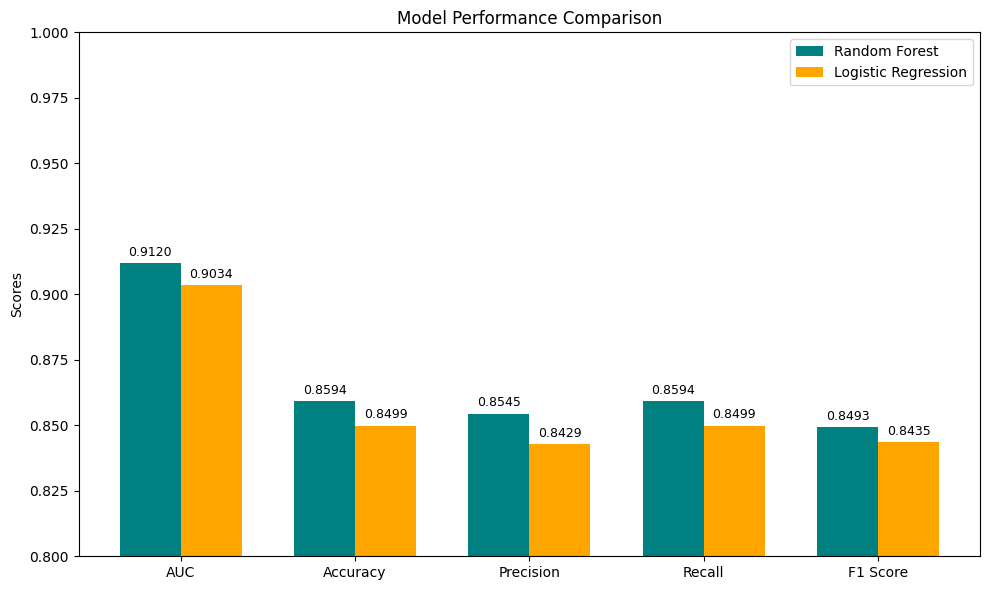

In [34]:
metrics_labels = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

rf_values = [test_auc_rf, accuracy_rf, precision_rf, recall_rf, f1_rf]
lr_values = [test_auc_lr, accuracy_lr, precision_lr, recall_lr, f1_lr]

x = np.arange(len(metrics_labels))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='teal')
rects2 = ax.bar(x + width/2, lr_values, width, label='Logistic Regression', color='orange')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0.8, 1.0) 

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

As observed from the graph, Random Forest outperforms Linear Regression in all metrics. For that reason, Random Forest is a better algorithm to classify high income people in this dataset.

---

## Step 6: Summary

### 1. Data Preprocessing
- Handle missing values by creating `Unknown` category for each categorical column
- Remove redundancy of `education` and `education_num` by removing `education` column
- Cleaning categorical columns by removing leading and trailing whitespaces

### 2. Feature Engineering
- Transform `income` column to binary values (0 and 1).
- Creating new features by:
    - Grouping `native_country` variable into `US` and `Others`
    - Creating `age_category` column based on `age`
    - Substracting `capital_loss` from `capital_gain` to create `net_capital`

### 3. Unsupervised Learning
-  Create a Pipeline for Unsupervised Learning, including:
    - Extracting numerical features
    - Using VectorAssembler to combine numerical features
    - Using StandardScaler to scale numerical features before putting it to PCA
    - Using PCA to reduce dimensionality to 2D for visualization

### 4. Data Visualization
- Group data by education level, calculate the percentage of individuals earning >$50K, convert to an ordered Pandas categorical, and render a gradient-filled bar chart with percentage labels using plotnine
- Extract age and label columns to Pandas, converted labels to strings for discrete treatment, and generate a boxplot comparing age distributions across income classes with custom color mapping
- Aggregate counts by occupation and label, merged totals to compute high-income percentages, sorted occupations by percentage, apply an ordered categorical for proper ranking, and display a horizontal bar chart with coordinate flipping

### 5. Modeling and Prediction
- Split the dataset in 80/20 ratio
- Creating a Pipeline for Supervised Learning, including:
    - Applying One Hot Encoder for categorical features
    - Using VectorAssembler to combine all features
    - Scale the data
- Training Logistic Regression with hyperparameter tuning and cross-validation
- Training Random Forest with hyperparameter tuning, cross-validation and feature importance extraction
- Comparing the performance of 2 models

## Step 7: Stop Session

In [35]:
spark.stop()